In [1]:
import json
import os
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import torch as t
import seaborn as sns
import sys
from pprint import pprint

sys.path.insert(0, '..')
from evaluate_circuit import get_edge_list, get_node_list


In [2]:
def load_circuit(model, exp_name, n):
    circuit_dir = f"../circuits/{model.split('/')[-1]}"
    f_path = [
        f for f in os.listdir(os.path.join(circuit_dir, exp_name)) if f.startswith(f"edges_asked{n}_simple")
    ][0]
    load_path = os.path.join(circuit_dir, exp_name, f_path)
    with open(load_path, 'r') as f:
        circuit = json.load(f)

    return circuit

In [10]:
results = t.load("../circuits/gemma-2-2b-it/logit_steer_harmless/patching_results.pt", map_location='cpu')
g2_edge_list, g2_up_names, g2_down_names = get_edge_list(results['edges'])

node_list = get_node_list(results['nodes'])

model_path = "google/gemma-2-2b-it"

In [3]:
def nodes_to_one_hot(circuit, node_list):
    enc = t.zeros(len(node_list))
    for i, (node, _) in enumerate(node_list):
        for edge in circuit:
            if node == edge['up'] or node == edge['down']:
                enc[i] = 1
                break
    return enc

def edges_to_one_hot(circuit, edge_list):
    enc = t.zeros(len(edge_list))
    for i, (up, down, _) in enumerate(edge_list):
        for edge in circuit:
            if up == edge['up'] and down == edge['down']:
                enc[i] = 1
                break

    return enc

def overlap(enc_1, enc_2):
    overlap = t.logical_and(enc_1, enc_2)
    num_edges_1 = enc_1.sum()
    num_edges_2 = enc_2.sum()
    return overlap.sum()/num_edges_1, overlap.sum()/num_edges_2

def overlap_small(enc_1, enc_2):
    overlap = t.logical_and(enc_1, enc_2)
    num_edges_1 = enc_1.sum()
    num_edges_2 = enc_2.sum()
    return overlap.sum()/t.min(num_edges_1, num_edges_2)

def jaccard_similarity(enc_1, enc_2):
    intersection = t.logical_and(enc_1, enc_2).sum()
    union = t.logical_or(enc_1, enc_2).sum()
    return intersection / union

def check_similarities(edge_list, circuits_y, circuits_x=None, with_random=False, overlap_fn='jaccard'):
    if overlap_fn == 'jaccard':
        sim_fn = jaccard_similarity
    elif overlap_fn == 'overlap':
        sim_fn = overlap_small
    if circuits_x is None:
        circuits_x = circuits_y
    def load_encs(circuits):
        vs = []
        for circuit in circuits:
            enc = edges_to_one_hot(circuit, edge_list)
            vs.append(enc)
        if with_random:
            n = int(enc.sum().item())
            enc = t.zeros(len(edge_list))
            rand_inds = t.randperm(len(edge_list))[:n]
            enc[rand_inds] = 1
            vs.append(enc)
        vs = t.stack(vs, dim=0)
        return vs
    
    vs_y = load_encs(circuits_y)
    vs_x = load_encs(circuits_x)
    
    sim_matrix = t.zeros(len(vs_y), len(vs_x))
    for i in range(len(vs_y)):
        for j in range(len(vs_x)):
            sim_matrix[i, j] = sim_fn(vs_y[i], vs_x[j])
    return sim_matrix, vs_y, vs_x

def check_node_similarities(node_list, circuits):
    vs = []
    for circuit in circuits:
        enc = nodes_to_one_hot(circuit, node_list)
        vs.append(enc)
    vs = t.stack(vs, dim=0)
    N = len(vs)
    sim_matrix = t.zeros(N, N)
    for i in range(N):
        for j in range(N):
            sim_matrix[i, j] = jaccard_similarity(vs[i], vs[j])
    return sim_matrix, vs

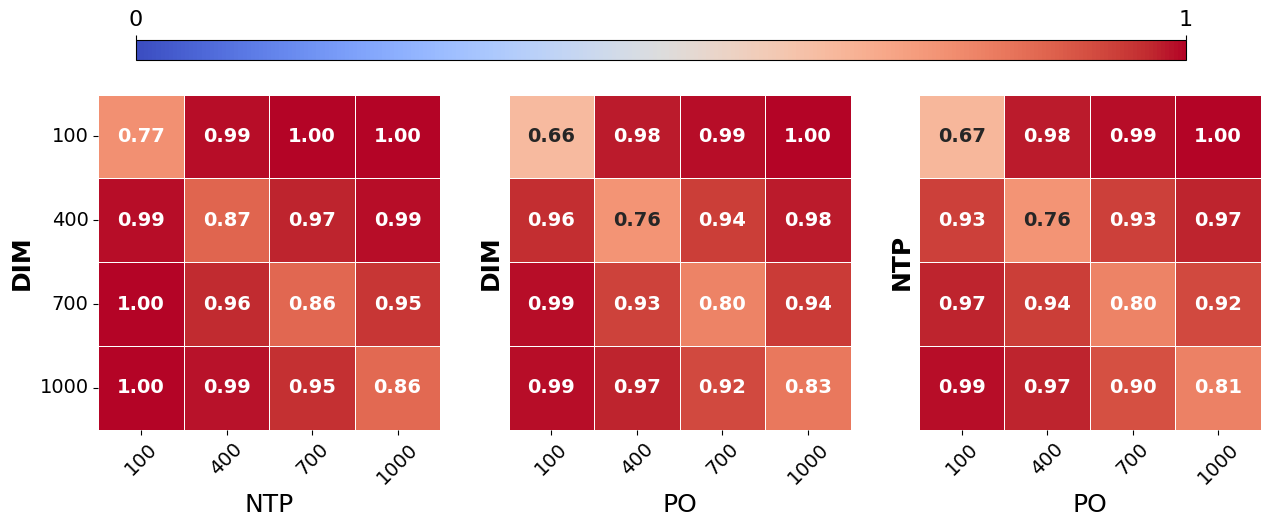

In [22]:
dim_circuits = []
ntp_circuits = []
reps_circuits = []
ns = [100, 400, 700, 1000]
for n in ns:
    dim_circuits.append(load_circuit(model_path, "dim_logit", n))
    ntp_circuits.append(load_circuit(model_path, "ntp_logit", n))
    reps_circuits.append(load_circuit(model_path, "reps_logit", n))


S_dim_ntp, V_dim, V_ntp = check_similarities(g2_edge_list, dim_circuits, ntp_circuits, with_random=False, overlap_fn='overlap')
S_dim_reps, V_reps, V_ntp = check_similarities(g2_edge_list, dim_circuits, reps_circuits, with_random=False, overlap_fn='overlap')
S_ntp_reps, V_ntp, V_reps = check_similarities(g2_edge_list, ntp_circuits, reps_circuits, with_random=False, overlap_fn='overlap')

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

Ss = [S_dim_ntp, S_dim_reps, S_ntp_reps]
# subtitles = ['DIM vs NTP', 'dim, reps', 'ntp, reps']
tick_labels = ns
y_labels = ['DIM', 'DIM', 'NTP']
x_labels = ['NTP', 'PO', 'PO']
for i in range(3):
    sns.heatmap(
        Ss[i].numpy(),
        ax=axs[i],
        annot=True, fmt=".2f",
        annot_kws={'size':14, 'fontweight': 'bold'},
        xticklabels=tick_labels, 
        yticklabels=tick_labels,
        cmap="coolwarm", vmin=0, vmax=1.0,
        linewidths=0.5, linecolor="white",
        cbar=False,
    )
    axs[i].set_xlabel(x_labels[i], fontsize=18)
    axs[i].set_ylabel(y_labels[i], fontsize=18, fontweight='bold')
    axs[i].tick_params(axis="x", rotation=45, labelsize=14)
    if i == 0:
        axs[i].tick_params(axis="y", rotation=0, labelsize=14)
    else:
        axs[i].set_yticks([])
    # axs[i].set_title(f"{subtitles[i]}", fontsize=13)

norm = mpl.colors.Normalize(vmin=0, vmax=1.0)
sm = mpl.cm.ScalarMappable(cmap="coolwarm", norm=norm)
sm.set_array([])
fig.subplots_adjust(top=0.78, wspace=0.2)
cbar_ax = fig.add_axes([0.15, 0.85, 0.7, 0.04])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_ticks([0,1])
cbar.ax.tick_params(labelsize=16, top=True, labeltop=True, bottom=False, labelbottom=False)
# fig.subplots_adjust(right=0.88, wspace=0.3)
# cbar_ax = fig.add_axes([0.92, 0.15, 0.03, 0.7])
# cbar = fig.colorbar(sm, cax=cbar_ax)
# cbar.ax.tick_params(labelsize=18)

plt.savefig("circuit_overlap_g2.pdf", bbox_inches="tight")



Inspect circuit outgoing and incoming edges

In [7]:
def inspect_circuit(circuit_edges: list[tuple], up_names: list[str], down_names: list[str], all_edges: list[tuple]):
    up_count = {
        name: 0 for name in up_names
    }
    down_count = {
        name: 0 for name in down_names
    }
    out_type_names = {
        'mlp': set(),
        'resid': set(),
        'attn': set(),
    }
    total_out_type_names = {
        'mlp': set(),
        'resid': set(),
        'attn': set(),
    }
    out_type_count = {
        'mlp': {'mlp': 0, 'attn_q': 0, 'attn_k': 0, 'attn_v': 0, 'lm_head': 0}, 
        'resid': {'mlp': 0, 'attn_q': 0, 'attn_k': 0, 'attn_v': 0, 'lm_head': 0}, 
        'attn': {'mlp': 0, 'attn_q': 0, 'attn_k': 0, 'attn_v': 0, 'lm_head': 0}
    }
    total_out_type_count = {
        'mlp': {'mlp': 0, 'attn_q': 0, 'attn_k': 0, 'attn_v': 0, 'lm_head': 0}, 
        'resid': {'mlp': 0, 'attn_q': 0, 'attn_k': 0, 'attn_v': 0, 'lm_head': 0}, 
        'attn': {'mlp': 0, 'attn_q': 0, 'attn_k': 0, 'attn_v': 0, 'lm_head': 0}
    }
    in_type_count = {
        'attn_q': {'mlp': 0, 'attn': 0, 'resid': 0}, 
        'attn_k': {'mlp': 0, 'attn': 0, 'resid': 0}, 
        'attn_v': {'mlp': 0, 'attn': 0, 'resid': 0}, 
        'mlp': {'mlp': 0, 'attn': 0, 'resid': 0}, 
        'lm_head': {'mlp': 0, 'attn': 0, 'resid': 0}, 
    }
    total_in_type_count = {
        'attn_q': {'mlp': 0, 'attn': 0, 'resid': 0}, 
        'attn_k': {'mlp': 0, 'attn': 0, 'resid': 0}, 
        'attn_v': {'mlp': 0, 'attn': 0, 'resid': 0}, 
        'mlp': {'mlp': 0, 'attn': 0, 'resid': 0}, 
        'lm_head': {'mlp': 0, 'attn': 0, 'resid': 0}, 
    }
    in_type_names = {
        'attn_q': set(),
        'attn_k': set(),
        'attn_v': set(),
        'mlp': set(),
        'lm_head': set()
    }
    total_in_type_names = {
        'attn_q': set(),
        'attn_k': set(),
        'attn_v': set(),
        'mlp': set(),
        'lm_head': set()
    }
    for edge in all_edges:
        up, down, score = edge
        up_type = up.split('_')[0]
        if down == 'lm_head':
            down_type = 'lm_head'
        elif down.startswith('mlp'):
            down_type = 'mlp'
        elif down.startswith('attn'):
            down_type = down.split('_')[0] + '_' + down.split('_')[-1]
        total_out_type_count[up_type][down_type] += 1
        total_in_type_count[down_type][up_type] += 1
        total_out_type_names[up_type].add(up)
        total_in_type_names[down_type].add(down)

    for edge in circuit_edges:
        up, down = edge['up'], edge['down']
        up_count[up] += 1
        down_count[down] += 1
        up_type = up.split('_')[0]
        if down == 'lm_head':
            down_type = 'lm_head'
        elif down.startswith('mlp'):
            down_type = 'mlp'
        elif down.startswith('attn'):
            down_type = down.split('_')[0] + '_' + down.split('_')[-1]
        out_type_count[up_type][down_type] += 1
        out_type_names[up_type].add(up)
        in_type_count[down_type][up_type] += 1
        in_type_names[down_type].add(down)
    # print(up_count)
    # print(down_count)
    print('circuit out type count')
    pprint(out_type_count)
    print('all edges out type count')
    pprint(total_out_type_count)
    print('circuit in type count')
    pprint(in_type_count)
    print('all edges in type count')
    pprint(total_in_type_count)
    
    print('out type names')
    for key, sets in out_type_names.items():
        print(f"{key}: {len(sets)}")
    print('total out type names')
    for key, sets in total_out_type_names.items():
        print(f"{key}: {len(sets)}")
    print('in type names')
    for key, sets in in_type_names.items():
        print(f"{key}: {len(sets)}")
    print('total in type names')
    for key, sets in total_in_type_names.items():
        print(f"{key}: {len(sets)}")

    return out_type_count, total_out_type_count, in_type_count, total_in_type_count

In [5]:
def inspect_circuit2(circuit: list[dict], edge_list: list[tuple]):
    
    out_nodes = set([up for up, down, _ in edge_list])
    counts = {
        node: 0 for node in out_nodes
    }
    for edge in circuit:
        up = edge['up']
        counts[up] += 1
    
    ranks = sorted(list(out_nodes), key=lambda n: counts[n], reverse=True)

    return counts, ranks

def get_ranked_subcircuit(circuit: list[dict], topp: float):
    edges = []
    for edge in circuit:
        edges.append((edge['up'], edge['down'], edge['score']))
    ranked_edges = sorted(edges, key=lambda x: x[2], reverse=True)

    topk = int(topp * len(ranked_edges))
    
    ranked_circuit = []
    for i in range(topk):
        up, down, score = ranked_edges[i]
        ranked_circuit.append({
            'up': up, 'down': down, 'score': score
        })
        up_type = up.split('_')[0]
        if down == 'lm_head':
            down_type = 'lm_head'
        elif down.startswith('mlp'):
            down_type = 'mlp'
        elif down.startswith('attn'):
            down_type = down.split('_')[0] + '_' + down.split('_')[-1]

    return ranked_circuit

In [11]:
n = 700
edge_list = g2_edge_list
model_path = 'google/gemma-2-2b-it'
dim_logit_circuit = load_circuit(model_path, "dim_logit", n)
ntp_logit_circuit = load_circuit(model_path, "ntp_logit", n)
reps_logit_circuit = load_circuit(model_path, "reps_logit", n)
inspect_circuit(dim_logit_circuit, g2_up_names, g2_down_names, edge_list)
print()
inspect_circuit(ntp_logit_circuit, g2_up_names, g2_down_names, edge_list)
print()
inspect_circuit(reps_logit_circuit, g2_up_names, g2_down_names, edge_list)


circuit out type count
{'attn': {'attn_k': 0, 'attn_q': 32, 'attn_v': 126, 'lm_head': 80, 'mlp': 306},
 'mlp': {'attn_k': 5, 'attn_q': 7, 'attn_v': 49, 'lm_head': 11, 'mlp': 50},
 'resid': {'attn_k': 2, 'attn_q': 9, 'attn_v': 11, 'lm_head': 1, 'mlp': 11}}
all edges out type count
{'attn': {'attn_k': 440,
          'attn_q': 440,
          'attn_v': 440,
          'lm_head': 88,
          'mlp': 528},
 'mlp': {'attn_k': 55, 'attn_q': 55, 'attn_v': 55, 'lm_head': 11, 'mlp': 55},
 'resid': {'attn_k': 11, 'attn_q': 11, 'attn_v': 11, 'lm_head': 1, 'mlp': 11}}
circuit in type count
{'attn_k': {'attn': 0, 'mlp': 5, 'resid': 2},
 'attn_q': {'attn': 32, 'mlp': 7, 'resid': 9},
 'attn_v': {'attn': 126, 'mlp': 49, 'resid': 11},
 'lm_head': {'attn': 80, 'mlp': 11, 'resid': 1},
 'mlp': {'attn': 306, 'mlp': 50, 'resid': 11}}
all edges in type count
{'attn_k': {'attn': 440, 'mlp': 55, 'resid': 11},
 'attn_q': {'attn': 440, 'mlp': 55, 'resid': 11},
 'attn_v': {'attn': 440, 'mlp': 55, 'resid': 11},
 'lm

({'mlp': {'mlp': 52, 'attn_q': 17, 'attn_k': 11, 'attn_v': 44, 'lm_head': 11},
  'resid': {'mlp': 11, 'attn_q': 10, 'attn_k': 1, 'attn_v': 11, 'lm_head': 1},
  'attn': {'mlp': 295,
   'attn_q': 26,
   'attn_k': 1,
   'attn_v': 127,
   'lm_head': 82}},
 {'mlp': {'mlp': 55, 'attn_q': 55, 'attn_k': 55, 'attn_v': 55, 'lm_head': 11},
  'resid': {'mlp': 11, 'attn_q': 11, 'attn_k': 11, 'attn_v': 11, 'lm_head': 1},
  'attn': {'mlp': 528,
   'attn_q': 440,
   'attn_k': 440,
   'attn_v': 440,
   'lm_head': 88}},
 {'attn_q': {'mlp': 17, 'attn': 26, 'resid': 10},
  'attn_k': {'mlp': 11, 'attn': 1, 'resid': 1},
  'attn_v': {'mlp': 44, 'attn': 127, 'resid': 11},
  'mlp': {'mlp': 52, 'attn': 295, 'resid': 11},
  'lm_head': {'mlp': 11, 'attn': 82, 'resid': 1}},
 {'attn_q': {'mlp': 55, 'attn': 440, 'resid': 11},
  'attn_k': {'mlp': 55, 'attn': 440, 'resid': 11},
  'attn_v': {'mlp': 55, 'attn': 440, 'resid': 11},
  'mlp': {'mlp': 55, 'attn': 528, 'resid': 11},
  'lm_head': {'mlp': 11, 'attn': 88, 'resid

In [ ]:
# find the top edges
n = 700
edge_list = g2_edge_list
dim_logit_circuit = load_circuit(model_path, "dim_logit", n)
ntp_logit_circuit = load_circuit(model_path, "ntp_logit", n)
reps_logit_circuit = load_circuit(model_path, "reps_logit", n)
dim_logit_subcircuit = get_ranked_subcircuit(dim_logit_circuit, 10/n)
ntp_logit_subcircuit = get_ranked_subcircuit(ntp_logit_circuit, 10/n)
reps_logit_subcircuit = get_ranked_subcircuit(reps_logit_circuit, 50/n)
inspect_circuit(dim_logit_subcircuit, up_names, down_names, edge_list)
print(dim_logit_subcircuit[:10])
print()
inspect_circuit(ntp_logit_subcircuit, up_names, down_names, edge_list)
print(ntp_logit_subcircuit[:10])
print()
inspect_circuit(reps_logit_subcircuit, up_names, down_names, edge_list)
print(reps_logit_subcircuit[:10])
print()

circuit out type count
{'attn': {'attn_k': 0, 'attn_q': 0, 'attn_v': 0, 'lm_head': 11, 'mlp': 8},
 'mlp': {'attn_k': 0, 'attn_q': 0, 'attn_v': 0, 'lm_head': 8, 'mlp': 9},
 'resid': {'attn_k': 0, 'attn_q': 0, 'attn_v': 5, 'lm_head': 1, 'mlp': 8}}
all edges out type count
{'attn': {'attn_k': 440,
          'attn_q': 440,
          'attn_v': 440,
          'lm_head': 88,
          'mlp': 528},
 'mlp': {'attn_k': 55, 'attn_q': 55, 'attn_v': 55, 'lm_head': 11, 'mlp': 55},
 'resid': {'attn_k': 11, 'attn_q': 11, 'attn_v': 11, 'lm_head': 1, 'mlp': 11}}
circuit in type count
{'attn_k': {'attn': 0, 'mlp': 0, 'resid': 0},
 'attn_q': {'attn': 0, 'mlp': 0, 'resid': 0},
 'attn_v': {'attn': 0, 'mlp': 0, 'resid': 5},
 'lm_head': {'attn': 11, 'mlp': 8, 'resid': 1},
 'mlp': {'attn': 8, 'mlp': 9, 'resid': 8}}
all edges in type count
{'attn_k': {'attn': 440, 'mlp': 55, 'resid': 11},
 'attn_q': {'attn': 440, 'mlp': 55, 'resid': 11},
 'attn_v': {'attn': 440, 'mlp': 55, 'resid': 11},
 'lm_head': {'attn': 88,

In [13]:
# find the top edges

results = t.load("../circuits/Llama-3.2-3B-Instruct/dim_logit/patching_results.pt", map_location='cpu')
l3_edge_list, up_names, down_names = get_edge_list(results['edges'])
n = 4200
dim_logit_circuit = load_circuit('meta-llama/Llama-3.2-3B-Instruct', "dim_logit", n)
# dim_logit_subcircuit = get_ranked_subcircuit(dim_logit_circuit, 600/n)
# inspect_circuit(dim_logit_circuit, up_names, down_names, l3_edge_list)
# print()
inspect_circuit(dim_logit_circuit, up_names, down_names, l3_edge_list)
# print(dim_logit_subcircuit[:10])
print()

circuit out type count
{'attn': {'attn_k': 178,
          'attn_q': 563,
          'attn_v': 895,
          'lm_head': 250,
          'mlp': 1823},
 'mlp': {'attn_k': 87, 'attn_q': 100, 'attn_v': 115, 'lm_head': 16, 'mlp': 119},
 'resid': {'attn_k': 7, 'attn_q': 14, 'attn_v': 16, 'lm_head': 1, 'mlp': 16}}
all edges out type count
{'attn': {'attn_k': 2880,
          'attn_q': 2880,
          'attn_v': 2880,
          'lm_head': 384,
          'mlp': 3264},
 'mlp': {'attn_k': 120,
         'attn_q': 120,
         'attn_v': 120,
         'lm_head': 16,
         'mlp': 120},
 'resid': {'attn_k': 16, 'attn_q': 16, 'attn_v': 16, 'lm_head': 1, 'mlp': 16}}
circuit in type count
{'attn_k': {'attn': 178, 'mlp': 87, 'resid': 7},
 'attn_q': {'attn': 563, 'mlp': 100, 'resid': 14},
 'attn_v': {'attn': 895, 'mlp': 115, 'resid': 16},
 'lm_head': {'attn': 250, 'mlp': 16, 'resid': 1},
 'mlp': {'attn': 1823, 'mlp': 119, 'resid': 16}}
all edges in type count
{'attn_k': {'attn': 2880, 'mlp': 120, 'resid': 

In [183]:
S, V = check_similarities(
    edge_list,
    [dim_logit_subcircuit, ntp_logit_subcircuit, reps_logit_subcircuit],
)
print(S)
print(V.sum(dim=-1))

tensor([[1.0000, 0.7544, 0.5873],
        [0.7544, 1.0000, 0.5267],
        [0.5873, 0.5267, 1.0000]])
tensor([100., 100., 100.])


In [ ]:
def pie_chart(percentages, labels, title=None):
    palette = sns.color_palette("pastel", len(labels))
    fig, ax = plt.subplots()
    ax.pie(percentages, labels=labels, colors=palette, autopct="%1.1f%%", startangle=90)
    ax.axis("equal")
    if title:
        ax.set_title(title)
    plt.tight_layout()
    plt.show()
    return fig, ax

In [ ]:
# get percentages and labels
out_labels = ["Attention Head", "MLP, Residual"]
